In [28]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint

# -------------------------
# SEIR MODEL
# -------------------------

def seir_model(y, t, beta, sigma, gamma, N):

    S, E, I, R = y

    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I

    return [dSdt, dEdt, dIdt, dRdt]


# -------------------------
# SIMULATION
# -------------------------

def simulate_seir(R0, sigma, gamma, N, I0=1, E0=0, days=365):

    beta = R0 * gamma

    S0 = N - I0 - E0
    R0_pop = 0

    y0 = [S0, E0, I0, R0_pop]

    t = np.linspace(0, days, days)

    solution = odeint(seir_model, y0, t, args=(beta, sigma, gamma, N))

    S, E, I, R = solution.T

    Rt = R0 * (S / N)

    return t, S, E, I, R, Rt


# -------------------------
# OUTBREAK DURATION
# -------------------------

def outbreak_duration(Rt, t):

    active = Rt > 1

    if np.sum(active) == 0:
        return 0

    start = np.where(active)[0][0]
    end = np.where(active)[0][-1]

    return t[end] - t[start]


# -------------------------
# PARAMETER GRID
# -------------------------

def run_phase_portrait():

    R0_values = np.linspace(1.1, 2.5, 30)
    population_values = np.logspace(3, 7, 30)

    sigma = 1/1.5   # incubation ~1.5 days
    gamma = 1/3     # infectious ~3 days

    results = []

    for R0 in R0_values:

        for N in population_values:

            t, S, E, I, R, Rt = simulate_seir(R0, sigma, gamma, int(N))

            duration = outbreak_duration(Rt, t)

            results.append({
                "R0": R0,
                "population": N,
                "duration": duration
            })

    return pd.DataFrame(results)

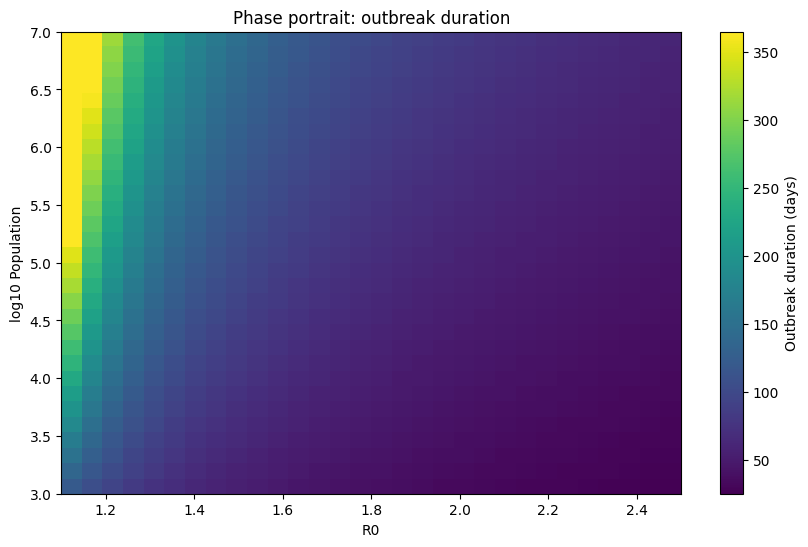

In [29]:
import matplotlib.pyplot as plt

df = run_phase_portrait()

pivot = df.pivot(index="population", columns="R0", values="duration")

plt.figure(figsize=(10,6))

plt.imshow(
    pivot,
    aspect="auto",
    origin="lower",
    extent=[
        df.R0.min(),
        df.R0.max(),
        np.log10(df.population.min()),
        np.log10(df.population.max())
    ]
)

plt.colorbar(label="Outbreak duration (days)")

plt.xlabel("R0")
plt.ylabel("log10 Population")

plt.title("Phase portrait: outbreak duration")

plt.show()

In [3]:
np.log10(11451999)

7.058881301426535

In [4]:
np.log10(833)

2.9206450014067875

In [6]:
100/7

14.285714285714286

In [30]:


def plot_epidemic_with_duration(R0, N, sigma=1/1.5, gamma=1/3):

    # simulate
    t, S, E, I, R, Rt = simulate_seir(R0, sigma, gamma, N)

    # incidence (new cases)
    incidence = sigma * E

    # outbreak period
    active = Rt > 1

    if np.sum(active) > 0:
        start = t[np.where(active)[0][0]]
        end = t[np.where(active)[0][-1]]
    else:
        start, end = None, None

    d = round((end - start +1)/7,0)
    
    # plot
    plt.figure(figsize=(10,5))

    plt.plot(t, incidence, label="New cases (σE)", linewidth=2)

    if start is not None:
        plt.axvspan(start, end, alpha=0.25, label="Outbreak duration (Rt>1)")


    plt.xlabel("Time (days)")
    plt.ylabel("New cases")
    plt.title(f"SEIR epidemic curve\nR0={R0}, Population={N:,}, Duration in weeks={d}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

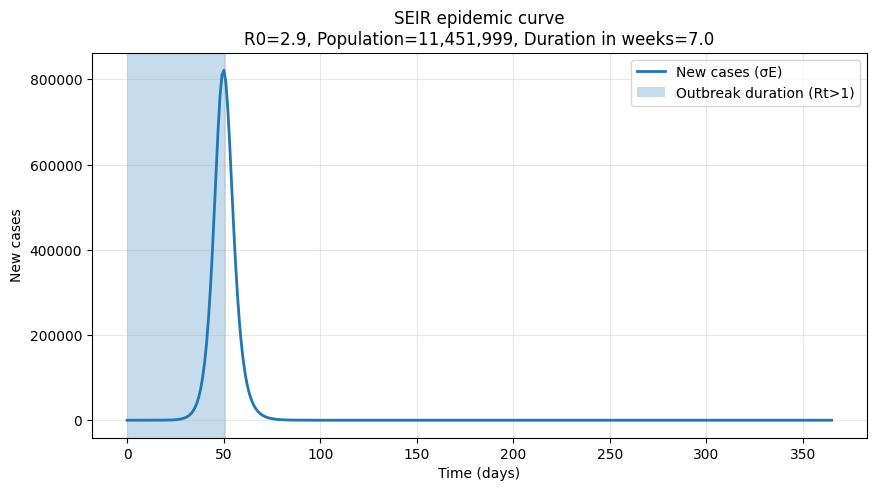

In [48]:
plot_epidemic_with_duration(
    R0=2.9,
    N=11451999
)

In [49]:
0.08*11451999

916159.92